In [1]:
from RiskMetrics.conformal_prediction import backtest_model, HistoricalVaR, ParametricVaR, EWMAVaR, ConformalPIDPredictor, AdaptiveConformalInference
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from features_definition import FEATURES, prepare_target_and_exog
import plotly.express as px

2025-12-09 23:11:56 - INFO - Fetching Page 1...
2025-12-09 23:11:56 - INFO - GET https://api.gridstatus.io/v1/datasets/caiso_lmp_day_ahead_hourly/query
2025-12-09 23:11:56 - INFO - Params: {'start_time': Timestamp('2019-01-01 00:00:00'), 'end_time': Timestamp('2025-11-01 00:00:00'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': 'US/Pacific', 'cursor': '', 'filter_column': 'location', 'filter_value': 'TH_NP15_GEN-APND', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2025-12-09 23:12:17 - INFO - Done in 21.16 seconds. 
2025-12-09 23:12:17 - INFO - Fetching Page 2...
2025-12-09 23:12:17 - INFO - GET https://api.gridstatus.io/v1/datasets/caiso_lmp_day_ahead_hourly/query
2025-12-09 23:12:17 - INFO - Params: {'start_time': Timestamp('2019-01-01 00:00:00'), 'end_time': Timestamp('2025-11-01 00:00:

# Available Features

In [2]:
FEATURES

,time,location,location_type,market,interval_start_local,interval_start_utc,interval_end_local,interval_end_utc,lmp,energy,...,N9103US3,N9130US3,NA1504_SMI_4,NA1504_SMN_4,NA1504_SMO_4,NA1504_SMT_4,NA1504_SNE_4,NA1504_SSD_4,NA1504_SWI_4,NA1504_SWV_4
0,2019-03-21 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2019-03-21 11:30:00-07:00,2019-03-21 18:30:00+00:00,2019-03-21 12:30:00-07:00,2019-03-21 19:30:00+00:00,27.842002,29.237221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-03-22 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2019-03-22 11:30:00-07:00,2019-03-22 18:30:00+00:00,2019-03-22 12:30:00-07:00,2019-03-22 19:30:00+00:00,28.597104,29.795286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-23 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2019-03-23 11:30:00-07:00,2019-03-23 18:30:00+00:00,2019-03-23 12:30:00-07:00,2019-03-23 19:30:00+00:00,19.806030,21.160374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-03-24 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2019-03-24 11:30:00-07:00,2019-03-24 18:30:00+00:00,2019-03-24 12:30:00-07:00,2019-03-24 19:30:00+00:00,24.317408,25.800724,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-03-25 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2019-03-25 11:30:00-07:00,2019-03-25 18:30:00+00:00,2019-03-25 12:30:00-07:00,2019-03-25 19:30:00+00:00,30.547609,32.247578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2411,2025-10-27 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2025-10-27 11:30:00-07:00,2025-10-27 18:30:00+00:00,2025-10-27 12:30:00-07:00,2025-10-27 19:30:00+00:00,41.223550,36.999012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2412,2025-10-28 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2025-10-28 11:30:00-07:00,2025-10-28 18:30:00+00:00,2025-10-28 12:30:00-07:00,2025-10-28 19:30:00+00:00,45.849014,43.828647,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2413,2025-10-29 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2025-10-29 11:30:00-07:00,2025-10-29 18:30:00+00:00,2025-10-29 12:30:00-07:00,2025-10-29 19:30:00+00:00,46.938506,46.579652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2414,2025-10-30 00:00:00-07:00,TH_NP15_GEN-APND,Trading Hub,DAY_AHEAD_HOURLY,2025-10-30 11:30:00-07:00,2025-10-30 18:30:00+00:00,2025-10-30 12:30:00-07:00,2025-10-30 19:30:00+00:00,46.526720,45.142960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Prepare Data

In [3]:
exog_cols = [
    "heating_degrees",
    "cooling_degrees",
    "sunshine_fraction",
    "wind_squared",
    'lmp',
]
y, X, dates, exog_cols = prepare_target_and_exog(price_col='lmp', exog_cols=exog_cols)

/Users/juandiegopalaciosgodoy/Documents/Education/Columbia/MA Statistics/Fall 2025/MA Mentored Research Project/Library/ma_mentored_research_fall_2025/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/juandiegopalaciosgodoy/Documents/Education/Columbia/MA Statistics/Fall 2025/MA Mentored Research Project/Library/ma_mentored_research_fall_2025/features_definition.py:393: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.interpolate(method="pad", limit_direction="forward")
/Users/juandiegopalaciosgodoy/Documents/Education/Columbia/MA Statistics/Fall 2025/MA Mentored Research Project/Library/ma_mentored_research_fall_2025/features_definition.py:394: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.b

# Correlation

In [4]:
fig = px.imshow(pd.DataFrame(X, columns=exog_cols).corr())
fig.show()

# Run Backtest


RUN BACKTEST COMPARISON
Target Coverage: 95.0%

 Running Historical VaR
Coverage: 0.874

 Running Parametric VaR
Coverage: 0.909

 Running EWMA VaR
Coverage: 0.893

 Running Conformal P
SARIMAX Model Diagnostics
Order:           (5, 0, 0)
Seasonal order:  (4, 0, 0, 7)
Trend:           c
------------------------------------------------------------
AIC:  -817.822
BIC:  -739.835
HQIC: -788.134
Log-likelihood: 424.911
------------------------------------------------------------
Residual summary:
  Mean: 0.000962
  Std:  0.163677
  Min:  -1.120504
  Max:  1.097539
------------------------------------------------------------
Ljung–Box test (lag=100):
  Statistic: 115.621
  p-value:   0.136
  => Fail to reject H0: no strong evidence of autocorrelation.
------------------------------------------------------------
Jarque–Bera normality test:
  Statistic: 4431.804
  p-value:   0.000
  Skewness:  -0.318
  Kurtosis:  13.294
  => Reject H0: residuals are not normally distributed.
                 

KeyboardInterrupt: 

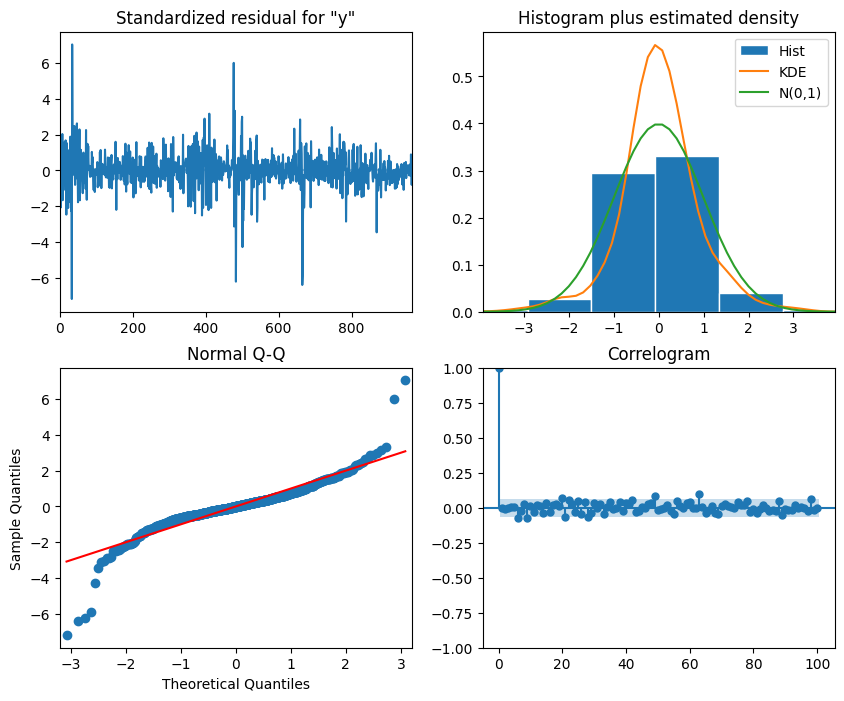

In [10]:
predictor_name='sarimax'
predictor_params={'order':(4,0,0), 'seasonal_order':(4,0,0,7)}
train_size = 1000
alpha = 0.05
all_results = {}
all_details = {}

models = {
    'Historical VaR':HistoricalVaR(window_size=train_size),
    'Parametric VaR':ParametricVaR(window_size=train_size),
    'EWMA VaR':EWMAVaR(decay_factor=0.94, window_size=train_size),
    'Conformal P':ConformalPIDPredictor(predictor_name=predictor_name, predictor_params=predictor_params, window_size=train_size, learning_rate=0.1, use_integrator=False, use_scorecaster=False),
    'Conformal PI':ConformalPIDPredictor(predictor_name=predictor_name, predictor_params=predictor_params, window_size=train_size, learning_rate=0.1, use_integrator=True, use_scorecaster=False),
    'Conformal ACI':AdaptiveConformalInference(predictor_name=predictor_name, predictor_params=predictor_params, window_size=train_size, learning_rate=0.005, target_alpha=alpha),
}

print("\n" + "=" * 70)
print("RUN BACKTEST COMPARISON")
print(f"Target Coverage: {(1 - alpha) * 100}%")
print("=" * 70)

# Run Models
for model_name, model in models.items():
    print(f"\n Running {model_name}")
    all_results[model_name], all_details[model_name] = backtest_model(model=model, dates=dates.tolist(), data=y, X=X, train_size=train_size, alpha=alpha, model_name=model_name)
    print(f"Coverage: {all_results[model_name].coverage:.3f}")

print("\n" + "=" * 70)
print("BACKTEST COMPLETE")
print("=" * 70)

# Backtest Summary Table

In [20]:
# CREATE SUMMARY TABLE
summary_data = []
for name, result in all_results.items():
    summary_data.append({
        'Method': name,
        'Coverage': f"{result.coverage:.1%}",
        'Target': f'{result.target_coverage:.1%}',
        'Coverage Gap': f'{(result.coverage - result.target_coverage) * 100:+.1f}%',
        'Violations': result.violations,
        'Average Width': f'{result.avg_interval_width:.4f}',
        'Kupiec p-value': f'{result.kupiec_pvalue:.3f}',
        'Christoff. p-value': f'{result.conditional_coverage_pvalue:.3f}'
    })

summary_df = pd.DataFrame(summary_data)
print('\n' + summary_df.to_string(index=False))


        Method Coverage Target Coverage Gap  Violations Average Width Kupiec p-value Christoff. p-value
Historical VaR    87.4%  95.0%        -7.6%         178        0.5776          0.000              0.000
Parametric VaR    90.9%  95.0%        -4.1%         129        0.6832          0.000              0.000
      EWMA VaR    89.3%  95.0%        -5.7%         151        0.6663          0.000              0.000
   Conformal P    95.0%  95.0%        +0.0%          70        0.9734          0.946              0.000
  Conformal PI    95.0%  95.0%        +0.0%          70        0.9739          0.946              0.000
 Conformal ACI    95.0%  95.0%        +0.0%          70        0.9245          0.946              0.000


# Results

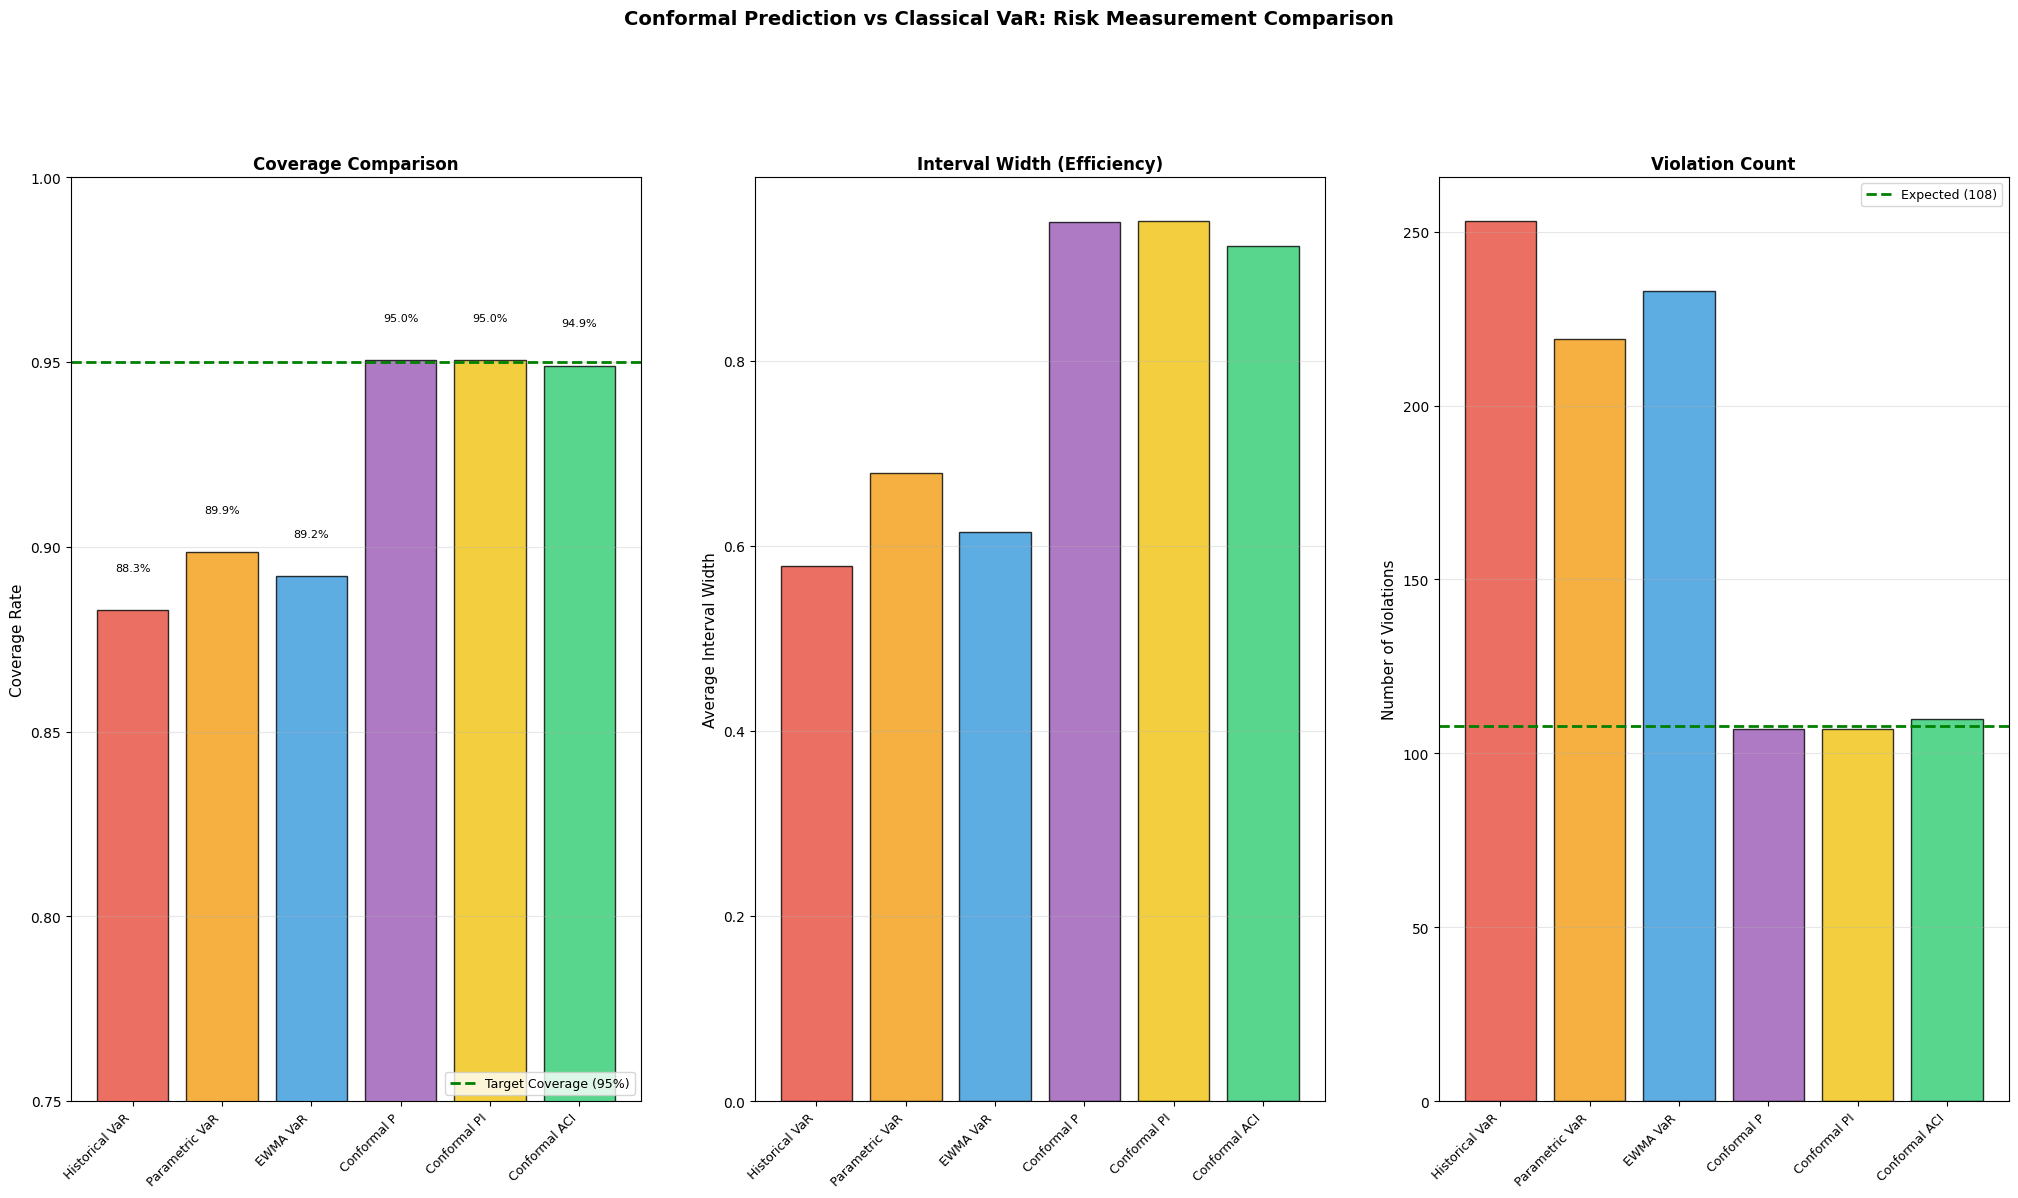

In [9]:
# COVERAGE COMPARISON BAR CHART
from plots.risk import plot_coverage_comparison

plot_coverage_comparison(results=all_results)

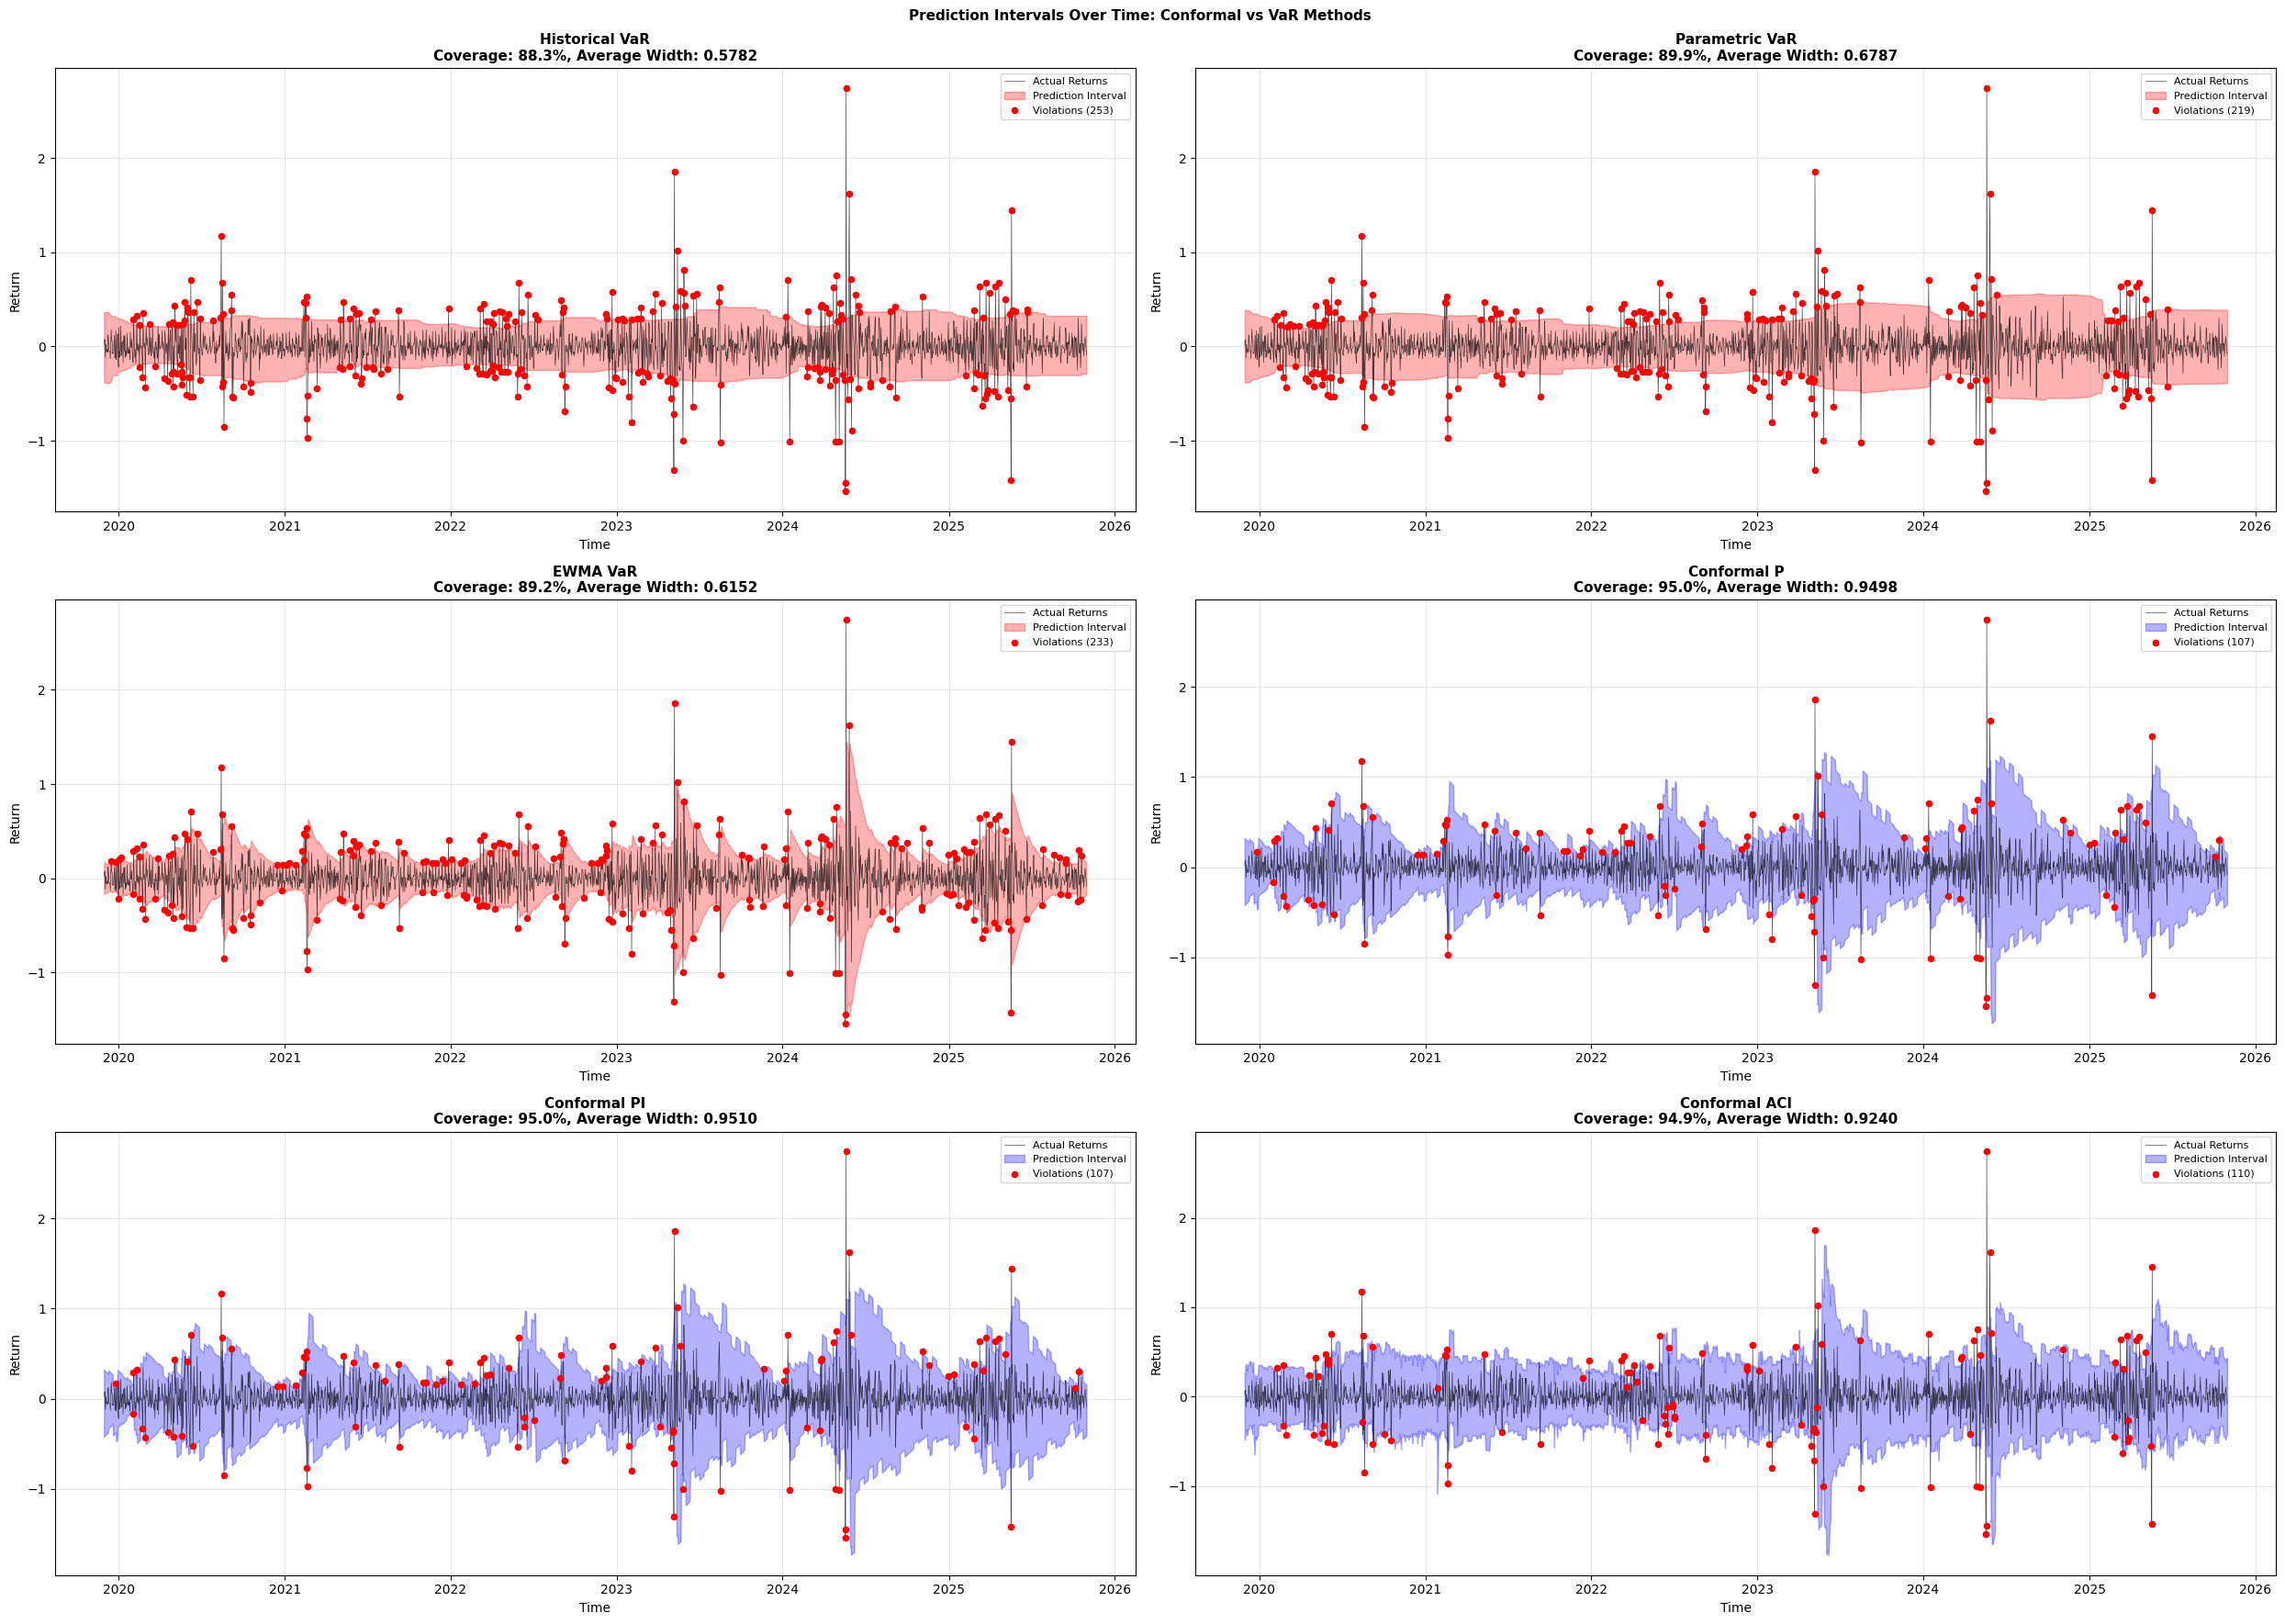

In [10]:
from plots.risk import plot_prediction_intervals
plot_prediction_intervals(results=all_results, details=all_details)

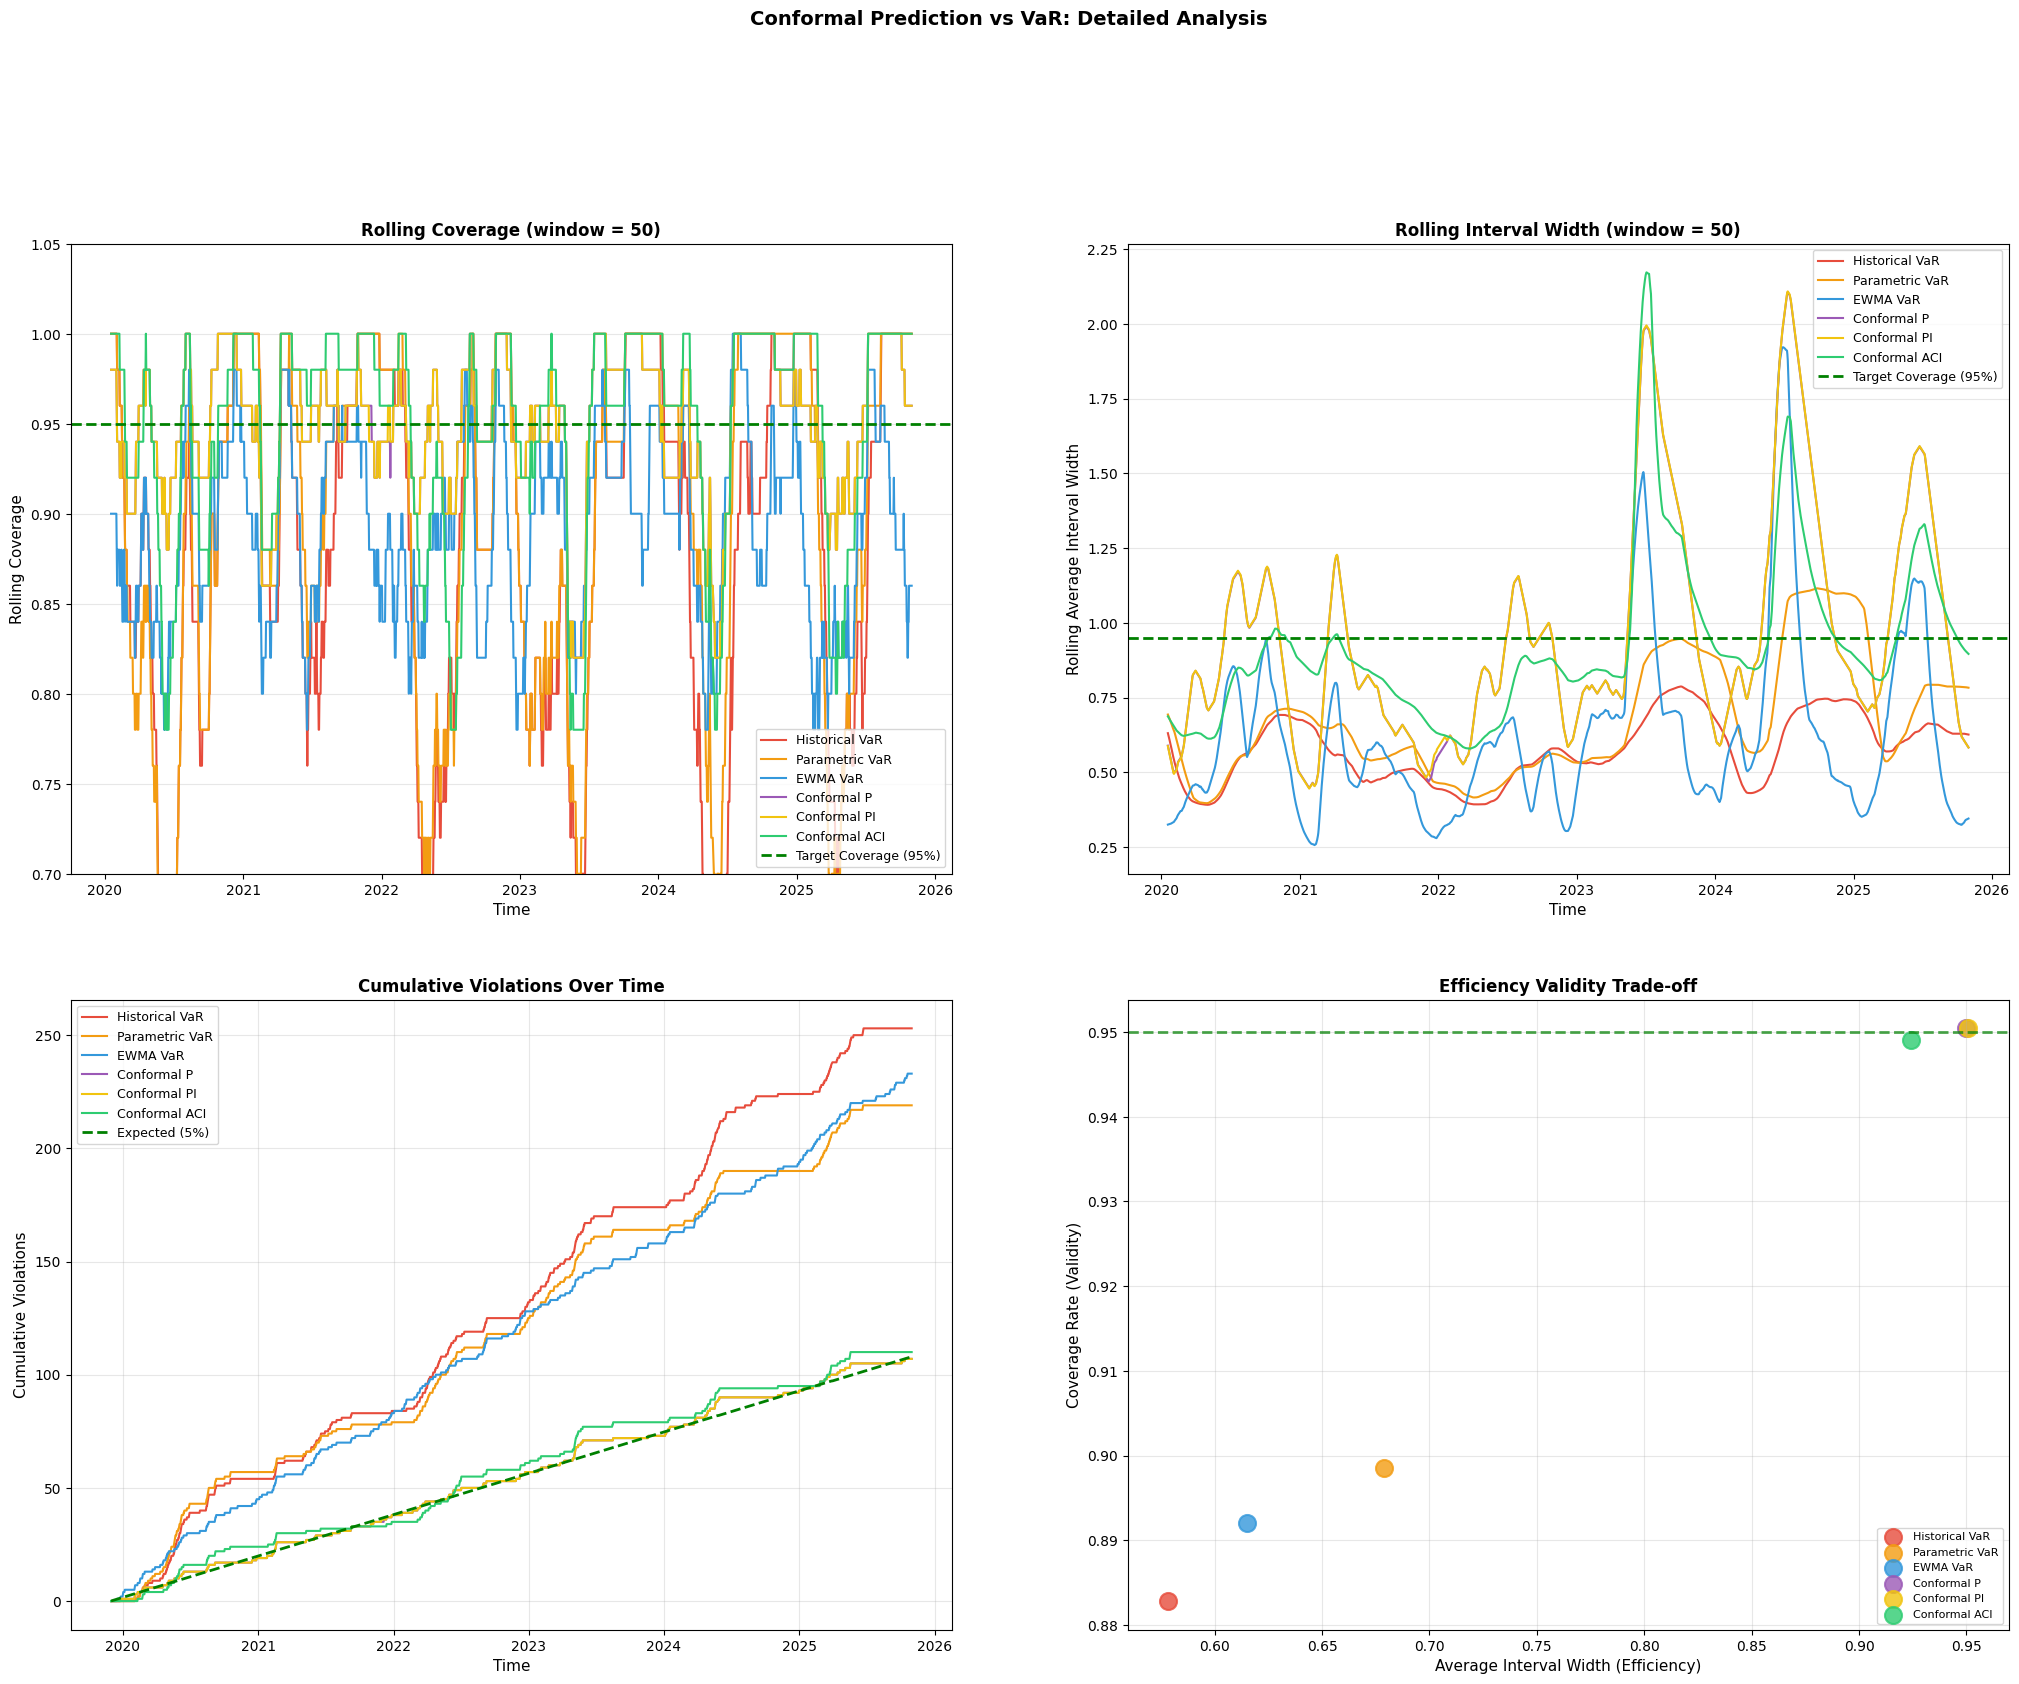

In [11]:
# TIME SERIES OF PREDICTION INTERVALS
from plots.risk import plot_rolling_statistics
plot_rolling_statistics(results=all_results, details=all_details)
